In [2]:
#masukan data set yang kita bbutuh kan

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
data_model = pd.read_csv('data_model_classificaton_banery.csv')
data_model.head(10)


,student_id,age,gender,course,year,daily_study_hours,daily_sleep_hours,screen_time_hours,stress_level,anxiety_score,depression_score,academic_pressure_score,financial_stress_score,social_support_score,physical_activity_hours,sleep_quality,attendance_percentage,cgpa,internet_quality,burnout_binary
0,100001,23,Male,BTech,1st,4.3,6.8,6.1,High,10,3,4,2,6,1.8,Average,66.5,9.63,Good,1
1,100002,20,Male,BTech,3rd,1.4,4.7,3.0,High,2,10,8,5,9,1.9,Poor,55.8,6.04,Poor,0
2,100003,24,Female,BCA,4th,3.7,4.8,1.5,Low,2,7,8,6,3,0.8,Good,85.0,8.31,Good,1
3,100004,21,Male,BSc,4th,1.6,6.7,7.0,High,3,3,4,9,9,0.7,Poor,89.1,5.95,Good,1
4,100005,23,Other,BSc,4th,2.0,6.7,5.4,High,7,7,6,4,4,1.7,Good,58.7,8.51,Good,0
5,100006,19,Male,BSc,3rd,8.2,4.8,4.1,High,8,4,9,8,2,1.9,Poor,51.7,6.82,Average,0
6,100007,23,Other,BSc,2nd,3.0,8.0,7.8,Low,5,9,9,2,6,0.5,Average,77.1,5.36,Average,0
7,100008,24,Male,BTech,2nd,4.6,6.3,7.6,Medium,5,10,3,10,6,0.6,Poor,59.3,5.91,Average,0
8,100009,21,Male,MBA,3rd,8.1,5.4,1.3,Low,1,1,7,2,1,1.7,Average,70.6,7.23,Average,0
9,100010,20,Male,BCA,3rd,9.7,7.0,11.5,Medium,4,2,4,3,7,1.3,Poor,65.0,6.26,Poor,1


In [3]:
#data clanning
data_model.info() #melihat informasi tentang data set kita
data_model.describe() #melihat statistik data seprti mean, median, juumlah data, data unique, dll

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 20 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   student_id               150000 non-null  int64  
 1   age                      150000 non-null  int64  
 2   gender                   150000 non-null  object 
 3   course                   150000 non-null  object 
 4   year                     150000 non-null  object 
 5   daily_study_hours        150000 non-null  float64
 6   daily_sleep_hours        150000 non-null  float64
 7   screen_time_hours        150000 non-null  float64
 8   stress_level             150000 non-null  object 
 9   anxiety_score            150000 non-null  int64  
 10  depression_score         150000 non-null  int64  
 11  academic_pressure_score  150000 non-null  int64  
 12  financial_stress_score   150000 non-null  int64  
 13  social_support_score     150000 non-null  int64  
 14  phys

,student_id,age,daily_study_hours,daily_sleep_hours,screen_time_hours,anxiety_score,depression_score,academic_pressure_score,financial_stress_score,social_support_score,physical_activity_hours,attendance_percentage,cgpa,burnout_binary
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000
mean,175000.500000,21.000380,5.507869,6.499361,6.502819,5.493907,5.497360,5.507427,5.496027,5.516060,0.998115,75.009528,6.997389,0.664900
std,43301.414527,2.581216,2.595592,1.443859,3.178948,2.872607,2.869022,2.875524,2.864698,2.870493,0.578866,14.409510,1.732180,0.472027
min,100001.000000,17.000000,1.000000,4.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,50.000000,4.000000,0.000000
25%,137500.750000,19.000000,3.300000,5.200000,3.700000,3.000000,3.000000,3.000000,3.000000,3.000000,0.500000,62.500000,5.500000,0.000000
50%,175000.500000,21.000000,5.500000,6.500000,6.500000,5.000000,5.000000,6.000000,6.000000,6.000000,1.000000,75.000000,6.990000,1.000000
75%,212500.250000,23.000000,7.700000,7.700000,9.300000,8.000000,8.000000,8.000000,8.000000,8.000000,1.500000,87.500000,8.500000,1.000000
max,250000.000000,25.000000,10.000000,9.000000,12.000000,10.000000,10.000000,10.000000,10.000000,10.000000,2.000000,100.000000,10.000000,1.000000


In [4]:
data_model.isnull().sum() #melihat missing value pada data set kita


student_id                 0
age                        0
gender                     0
course                     0
year                       0
daily_study_hours          0
daily_sleep_hours          0
screen_time_hours          0
stress_level               0
anxiety_score              0
depression_score           0
academic_pressure_score    0
financial_stress_score     0
social_support_score       0
physical_activity_hours    0
sleep_quality              0
attendance_percentage      0
cgpa                       0
internet_quality           0
burnout_binary             0
dtype: int64

In [5]:
data_model.duplicated().sum() #melihat data duplikat

0

In [6]:
data_finalmodel = data_model.drop(columns=['student_id'], axis=1) #menghapus kolom student_id karena tidak berpengaruh pada model kita
data_finalmodel.head(10)

,age,gender,course,year,daily_study_hours,daily_sleep_hours,screen_time_hours,stress_level,anxiety_score,depression_score,academic_pressure_score,financial_stress_score,social_support_score,physical_activity_hours,sleep_quality,attendance_percentage,cgpa,internet_quality,burnout_binary
0,23,Male,BTech,1st,4.3,6.8,6.1,High,10,3,4,2,6,1.8,Average,66.5,9.63,Good,1
1,20,Male,BTech,3rd,1.4,4.7,3.0,High,2,10,8,5,9,1.9,Poor,55.8,6.04,Poor,0
2,24,Female,BCA,4th,3.7,4.8,1.5,Low,2,7,8,6,3,0.8,Good,85.0,8.31,Good,1
3,21,Male,BSc,4th,1.6,6.7,7.0,High,3,3,4,9,9,0.7,Poor,89.1,5.95,Good,1
4,23,Other,BSc,4th,2.0,6.7,5.4,High,7,7,6,4,4,1.7,Good,58.7,8.51,Good,0
5,19,Male,BSc,3rd,8.2,4.8,4.1,High,8,4,9,8,2,1.9,Poor,51.7,6.82,Average,0
6,23,Other,BSc,2nd,3.0,8.0,7.8,Low,5,9,9,2,6,0.5,Average,77.1,5.36,Average,0
7,24,Male,BTech,2nd,4.6,6.3,7.6,Medium,5,10,3,10,6,0.6,Poor,59.3,5.91,Average,0
8,21,Male,MBA,3rd,8.1,5.4,1.3,Low,1,1,7,2,1,1.7,Average,70.6,7.23,Average,0
9,20,Male,BCA,3rd,9.7,7.0,11.5,Medium,4,2,4,3,7,1.3,Poor,65.0,6.26,Poor,1


In [7]:
data_finalmodel.tail(10) #melihat 10 data terakhir pada data set kita

,age,gender,course,year,daily_study_hours,daily_sleep_hours,screen_time_hours,stress_level,anxiety_score,depression_score,academic_pressure_score,financial_stress_score,social_support_score,physical_activity_hours,sleep_quality,attendance_percentage,cgpa,internet_quality,burnout_binary
149990,18,Female,BTech,1st,6.3,7.7,1.6,High,9,6,4,5,2,1.5,Average,89.8,5.48,Good,1
149991,17,Female,MCA,4th,7.0,6.7,10.2,Medium,10,4,1,4,8,0.3,Good,86.1,4.67,Average,1
149992,21,Male,BTech,4th,5.4,8.5,9.7,Low,7,5,7,1,7,1.6,Good,52.3,6.35,Good,1
149993,17,Female,BCA,4th,8.7,7.3,3.5,Medium,9,1,7,9,7,1.8,Poor,99.8,4.31,Good,1
149994,20,Male,MCA,4th,6.3,5.4,9.6,Medium,9,5,10,8,1,0.6,Good,77.2,9.31,Good,0
149995,24,Female,BSc,3rd,1.6,8.2,11.3,Medium,9,9,5,3,10,2.0,Good,54.2,7.82,Good,0
149996,25,Male,BCA,3rd,9.9,4.8,1.6,High,10,3,10,10,2,0.1,Poor,53.6,7.19,Average,1
149997,22,Male,BTech,1st,1.4,4.4,4.6,High,10,8,6,4,7,1.6,Good,90.7,9.78,Average,1
149998,19,Male,BSc,3rd,1.5,4.3,1.1,Medium,8,6,5,7,4,1.1,Average,83.9,9.88,Average,1
149999,20,Male,MCA,3rd,3.7,6.6,2.6,Medium,5,1,5,7,6,1.8,Good,89.8,7.00,Poor,1


In [8]:
data_finalmodel.describe()

,age,daily_study_hours,daily_sleep_hours,screen_time_hours,anxiety_score,depression_score,academic_pressure_score,financial_stress_score,social_support_score,physical_activity_hours,attendance_percentage,cgpa,burnout_binary
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000
mean,21.000380,5.507869,6.499361,6.502819,5.493907,5.497360,5.507427,5.496027,5.516060,0.998115,75.009528,6.997389,0.664900
std,2.581216,2.595592,1.443859,3.178948,2.872607,2.869022,2.875524,2.864698,2.870493,0.578866,14.409510,1.732180,0.472027
min,17.000000,1.000000,4.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,50.000000,4.000000,0.000000
25%,19.000000,3.300000,5.200000,3.700000,3.000000,3.000000,3.000000,3.000000,3.000000,0.500000,62.500000,5.500000,0.000000
50%,21.000000,5.500000,6.500000,6.500000,5.000000,5.000000,6.000000,6.000000,6.000000,1.000000,75.000000,6.990000,1.000000
75%,23.000000,7.700000,7.700000,9.300000,8.000000,8.000000,8.000000,8.000000,8.000000,1.500000,87.500000,8.500000,1.000000
max,25.000000,10.000000,9.000000,12.000000,10.000000,10.000000,10.000000,10.000000,10.000000,2.000000,100.000000,10.000000,1.000000


In [9]:
#melihat nilai tengah di data set kita
#melihat data tengah untuk data numeri integer dan data numeri float
data_finalmodel[['age', 'daily_study_hours', 'daily_sleep_hours', 'screen_time_hours',
       'anxiety_score', 'depression_score', 'academic_pressure_score',
       'financial_stress_score', 'social_support_score',
       'physical_activity_hours', 'attendance_percentage', 'cgpa',
       'burnout_binary']].median()

age                        21.00
daily_study_hours           5.50
daily_sleep_hours           6.50
screen_time_hours           6.50
anxiety_score               5.00
depression_score            5.00
academic_pressure_score     6.00
financial_stress_score      6.00
social_support_score        6.00
physical_activity_hours     1.00
attendance_percentage      75.00
cgpa                        6.99
burnout_binary              1.00
dtype: float64

In [10]:
#melihat data tengah untuk data numeri integer

data_finalmodel[['age', 'anxiety_score', 'depression_score', 'academic_pressure_score',
       'financial_stress_score', 'social_support_score', 'burnout_binary']].median()

age                        21.0
anxiety_score               5.0
depression_score            5.0
academic_pressure_score     6.0
financial_stress_score      6.0
social_support_score        6.0
burnout_binary              1.0
dtype: float64

In [11]:
#melihat data yang tidak konsiten pada data set kita
data_finalmodel.select_dtypes(include='object').columns #melihat data yang bertipe object pada data set kita
data_finalmodel.select_dtypes(exclude=['object', 'float']).columns

Index(['age', 'anxiety_score', 'depression_score', 'academic_pressure_score',
       'financial_stress_score', 'social_support_score', 'burnout_binary'],
      dtype='object')

In [12]:
data_finalmodel[['gender', 'course', 'year', 'stress_level', 'sleep_quality',
       'internet_quality']].nunique() #melihat data yang tidak konsisten pada data set kita    

#disini saya tidak akan menghapus data uniqe in karna datanya memang serpti itu di dunia nyata

gender              3
course              6
year                4
stress_level        3
sleep_quality       3
internet_quality    3
dtype: int64

In [13]:
data_finalmodel['year'].unique() #melihat data yang tidak konsisten pada data set kita

array(['1st', '3rd', '4th', '2nd'], dtype=object)

In [17]:
#aspliting data set

x = data_finalmodel.drop(columns=['burnout_binary']) #memisahkan data fitur dengan data target
y = data_finalmodel['burnout_binary']

x_latih, x_uji, y_latih, y_uji = train_test_split(x, y, test_size= 0.3, random_state=42) #memisahkan data latih dan data uji dengan rasio 70:30

print(x.shape) #melihat jumlah data fitur
print(y.shape) #melihat jumlah data target

(150000, 18)
(150000,)


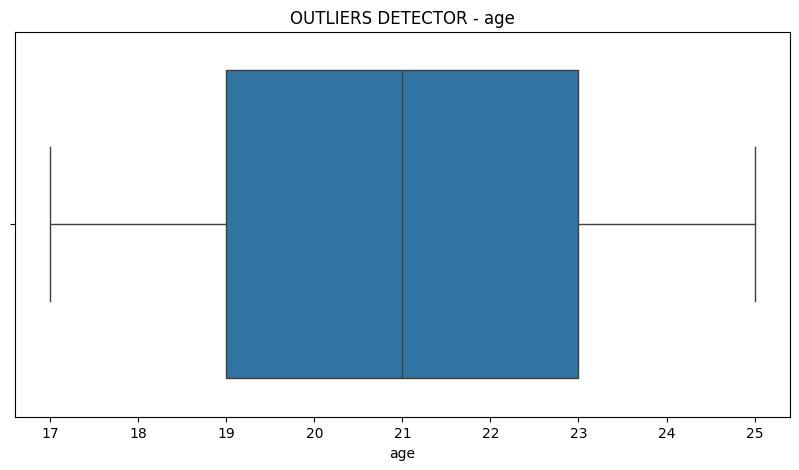

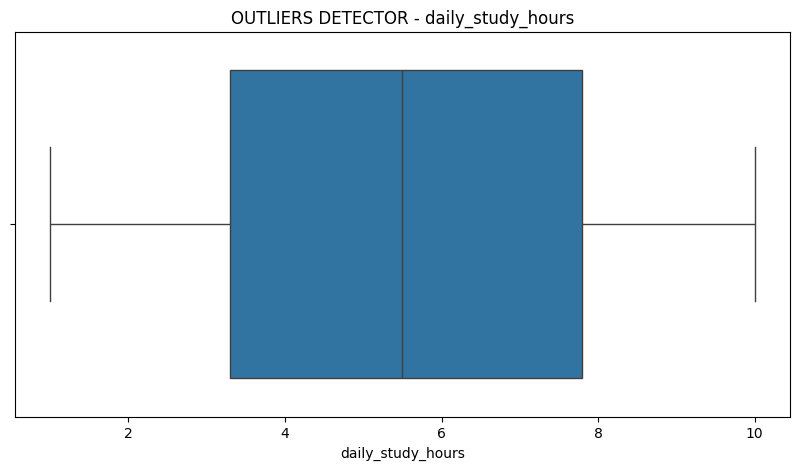

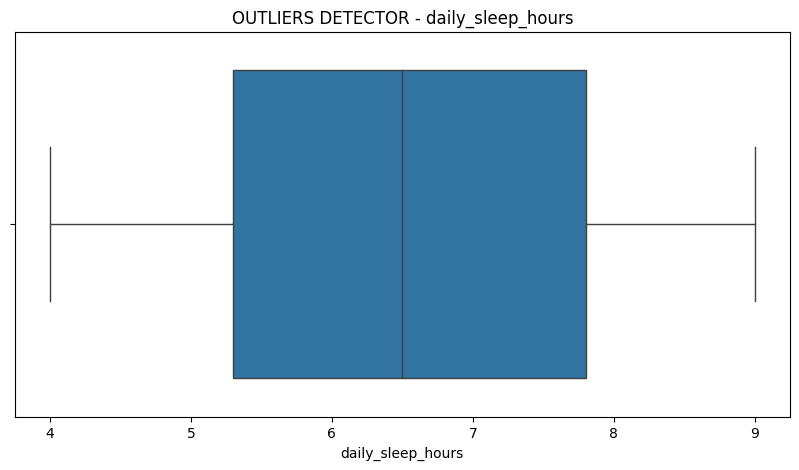

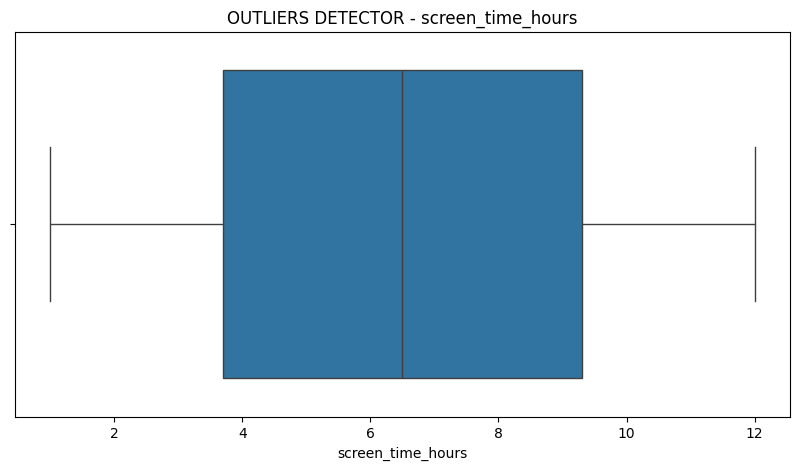

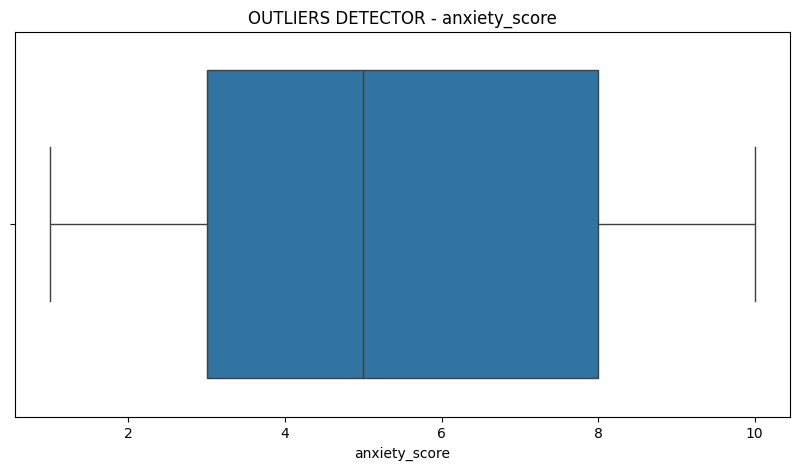

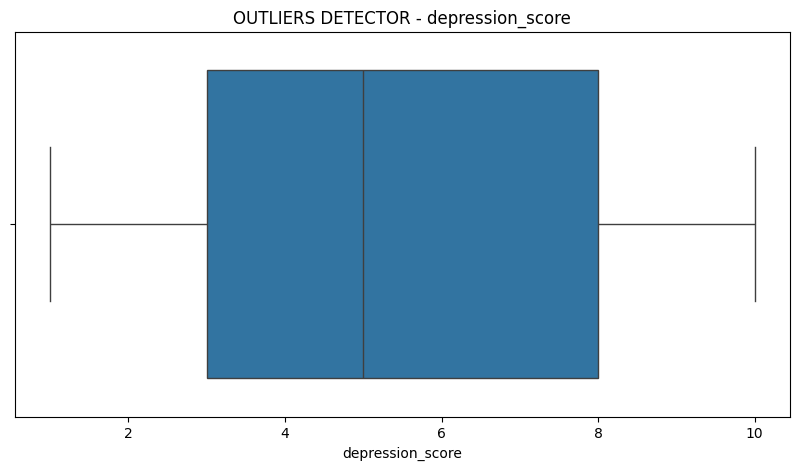

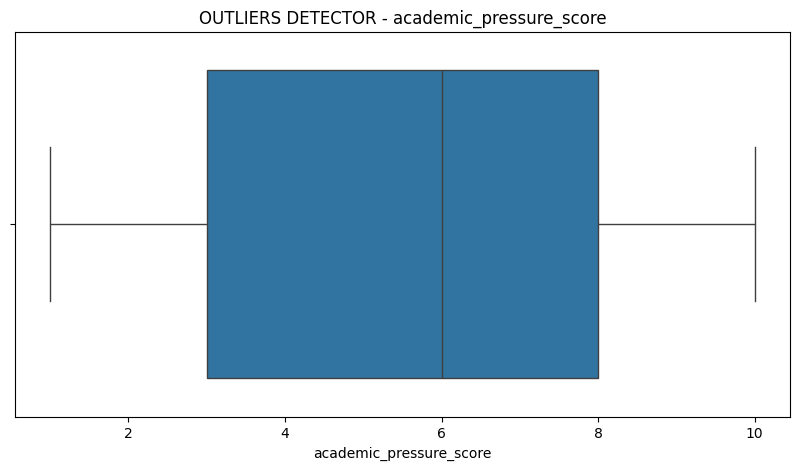

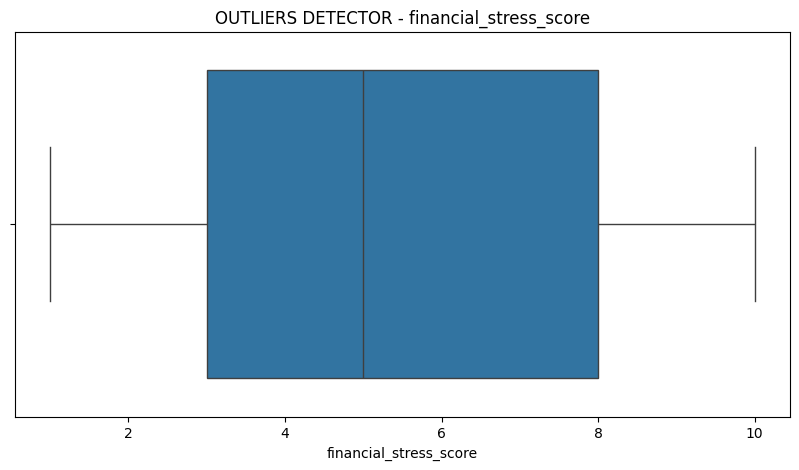

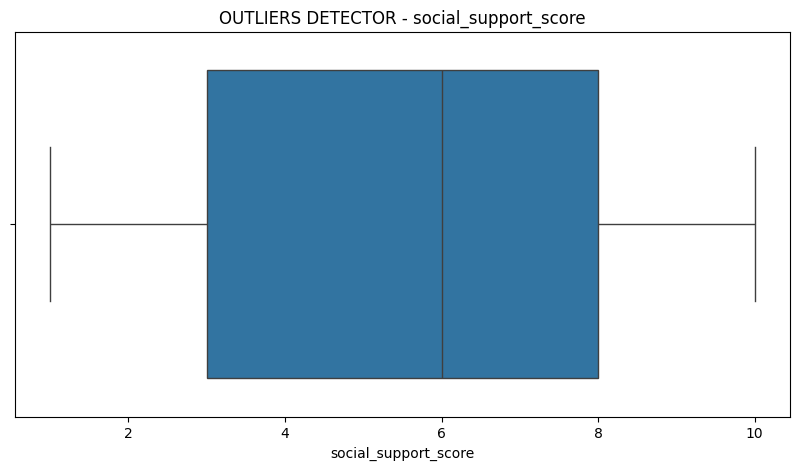

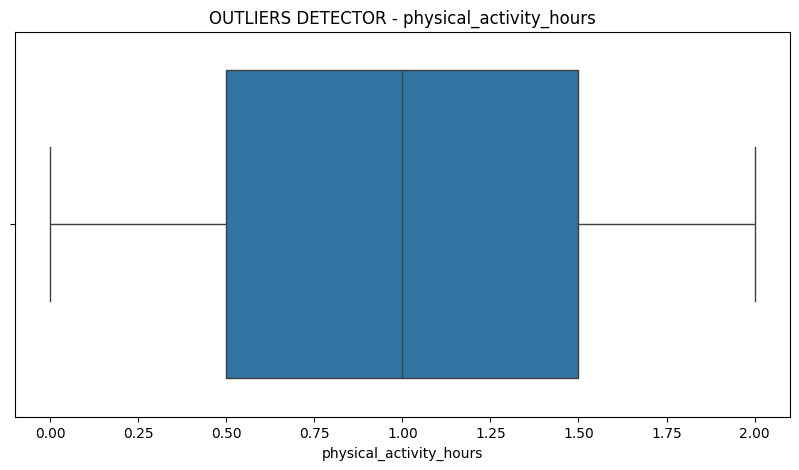

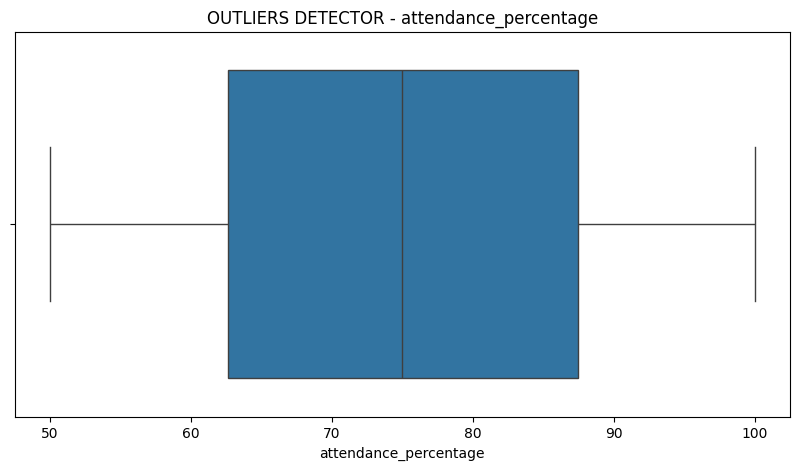

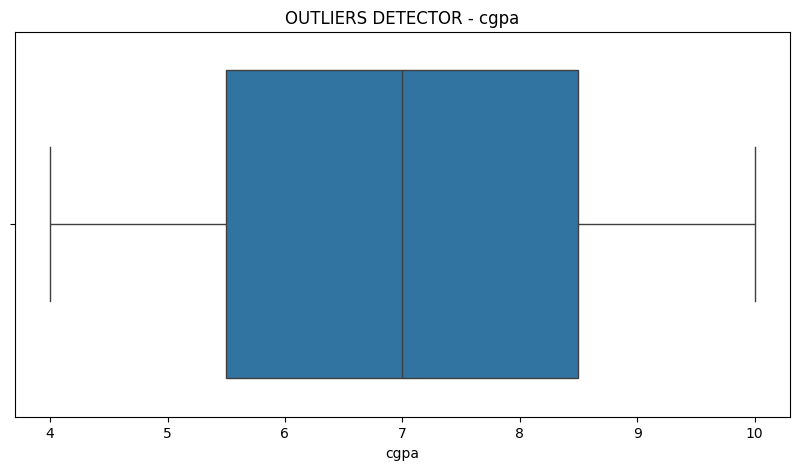

In [ ]:
#   EDA atau Exploratory Data Analysis
#DISTIRIBUTION DATA, MENGGUNAKAN UNIVARIATE ANALYSIS


#outlier detection
#kirta gunakan x_latih karna kita sudah spliting dahulu data nya
for column in x_latih.select_dtypes(include=['float64', 'int64']).columns: #disini kita menggabil data numerik saja karna outliers biasa nya hanya untuk data numerik
    plt.figure(figsize=(10, 5))
    sns.boxplot(x =x_latih[column])
    plt.title(f'OUTLIERS DETECTOR - {column}')
    plt.show()